<a href="https://colab.research.google.com/github/dy8656/ESM-Summer-School-2026---Mumax3/blob/main/mumax3_ESM_Summer_School_2026_Exercise_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mumax3 in google colaboratory - Solutions to the exercise**

This is a modified version of the google colab notbook provided by the mumax team at https://mumax.github.io/

## Installing mumax3

In [2]:
try:
    import google.colab
except ImportError:
    pass
else:
    # Download the mumax3 binary
    !wget https://mumax.ugent.be/mumax3-binaries/mumax3.12_linux_cuda12.9.tar.gz
    !tar -xvf mumax3.12_linux_cuda12.9.tar.gz
    !rm mumax3.12_linux_cuda12.9.tar.gz
    !rm -rf mumax3.12 && mv mumax3.12_linux_cuda12.9 mumax3.12
    #update the PATH environment variable
    import os
    os.environ['PATH'] += ":/content/mumax3.12"
    # Download an examplary script
    !wget https://raw.githubusercontent.com/JeroenMulkers/mumax3-tutorial/master/standardproblem4.mx3 -O standardproblem4.mx3

--2026-08-20 10:59:16--  https://mumax.ugent.be/mumax3-binaries/mumax3.12_linux_cuda12.9.tar.gz
Resolving mumax.ugent.be (mumax.ugent.be)... 157.193.40.77
Connecting to mumax.ugent.be (mumax.ugent.be)|157.193.40.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 287329660 (274M) [application/x-gzip]
Saving to: ‘mumax3.12_linux_cuda12.9.tar.gz’

mumax3.12_linux_cud 100%[===================>] 274.02M  22.4MB/s    in 13s     

2026-08-20 10:59:32 (20.7 MB/s) - ‘mumax3.12_linux_cuda12.9.tar.gz’ saved [287329660/287329660]

mumax3.12_linux_cuda12.9/
mumax3.12_linux_cuda12.9/LICENSE
mumax3.12_linux_cuda12.9/mumax3
mumax3.12_linux_cuda12.9/mumax3-server
mumax3.12_linux_cuda12.9/mumax3-convert
mumax3.12_linux_cuda12.9/lib/
mumax3.12_linux_cuda12.9/lib/libcurand.so.10
mumax3.12_linux_cuda12.9/lib/libcufft.so.11
--2026-08-20 10:59:38--  https://raw.githubusercontent.com/JeroenMulkers/mumax3-tutorial/master/standardproblem4.mx3
Resolving raw.githubusercontent.com (raw.gi

# Example 1 of the Mumax Tutorial - Phase diagram.

## Exercise 1
1. From the original setup, double the magnetocrystalline anisotropy. What do you observe and explain?
2. (Optional at home) Vary the magnetocrystaline anisotropy from 0.1 to 0.2 in 0.02 steps. Use just one input script for each magnetic configuration. Observe how the critical size, where the vortex state is the minimal energy state, as a function of the anisotropy.

## Solution Exercise 1.1

In [ ]:
f = open('example1b_exercise.mx3', 'w')
a = """\
N := 64
setgridsize(N,N,N)

Lmin := 8.0
Lmax := 10.0
Lstep := 0.05

L := Lmin
setcellsize(L/N,L/N,L/N)

Msat = sqrt(2/mu0)
Aex = 1.0
Ku1 = 0.2
anisU = vector(1,0,0)

m = uniform(1.0, 0, 0.001)

tableadd(E_total)
tableaddvar(L,"L","")

for L=Lmin ; L<=Lmax; L+=Lstep {
    setcellsize(L/N,L/N,L/N)
    minimize()
    tablesave()
}
"""
print(a,file=f)
f.close()

f = open('example1a_exercise.mx3', 'w')
a = """\
N := 64
setgridsize(N,N,N)

Lmin := 8.0
Lmax := 10.0
Lstep := 0.05

L := Lmin
setcellsize(L/N,L/N,L/N)

Msat = sqrt(2/mu0)
Aex = 1.0
Ku1 = 0.2
anisU = vector(1,0,0)

m = vortex(1,-1)

tableadd(E_total)
tableaddvar(L,"L","")

for L=Lmin ; L<=Lmax; L+=Lstep {
    setcellsize(L/N,L/N,L/N)
    minimize()
    tablesave()
}
"""
print(a,file=f)
f.close()


In [ ]:
!mumax3 example1a_exercise.mx3
!mumax3 example1b_exercise.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 11:16:15
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example1a_exercise.out/
//starting GUI at http://127.0.0.1:35367
N := 64
setgridsize(N, N, N)
Lmin := 8.0
Lmax := 10.0
Lstep := 0.05
L := Lmin
setcellsize(L/N, L/N, L/N)
Msat = sqrt(2 / mu0)
Aex = 1.0
Ku1 = 0.2
anisU = vector(1, 0, 0)
m = vortex(1, -1)
table

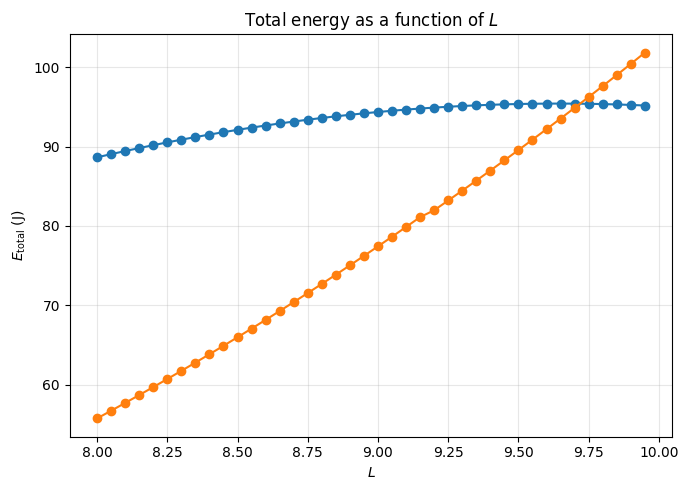

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the name of your data file
filename = "example1a_exercise.out/table.txt"

# Columns are counted from zero:
# 0: t, 1: mx, 2: my, 3: mz, 4: E_total, 5: L
E_total, L = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(4, 5),
    unpack=True
)

plt.figure(figsize=(7, 5))
plt.plot(L, E_total, marker="o", linestyle="-")

# Replace this with the name of your data file
filename = "example1b_exercise.out/table.txt"
E_total, L = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(4, 5),
    unpack=True
)
plt.plot(L, E_total, marker="o", linestyle="-")

plt.xlabel(r"$L$")
plt.ylabel(r"$E_{\mathrm{total}}$ (J)")
plt.title(r"Total energy as a function of $L$")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("E_total_vs_L.pdf")
plt.show()

## Solution Exercise 1.2
(this takes some time, approx 15min)

In [28]:
f = open('example1b_exercise12.mx3', 'w')
a = """\
N := 64
setgridsize(N,N,N)

Lmin := 8.0
Lmax := 10.0
Lstep := 0.05

L := Lmin
setcellsize(L/N,L/N,L/N)

Msat = sqrt(2/mu0)
Aex = 1.0
Ku1min := 0.1
Ku1max := 0.2
Ku1step := 0.02
K := Ku1min
anisU = vector(1,0,0)

m = uniform(1.0, 0, 0.001)

tableadd(E_total)
tableaddvar(L,"L","")
tableaddvar(K,"K","")

for K=Ku1min ; K<=Ku1max; K+=Ku1step {
    Ku1 = K
    for L=Lmin ; L<=Lmax; L+=Lstep {
        setcellsize(L/N,L/N,L/N)
        minimize()
        tablesave()
    }
}
"""
print(a,file=f)
f.close()

f = open('example1a_exercise12.mx3', 'w')
a = """\
N := 64
setgridsize(N,N,N)

Lmin := 8.0
Lmax := 10.0
Lstep := 0.05

L := Lmin
setcellsize(L/N,L/N,L/N)

Msat = sqrt(2/mu0)
Aex = 1.0
Ku1min := 0.1
Ku1max := 0.2
Ku1step := 0.02
K := Ku1min
anisU = vector(1,0,0)

m = vortex(1,-1)

tableadd(E_total)
tableaddvar(L,"L","")
tableaddvar(K,"K","")

for K=Ku1min ; K<=Ku1max; K+=Ku1step {
    Ku1 = K
    for L=Lmin ; L<=Lmax; L+=Lstep {
        setcellsize(L/N,L/N,L/N)
        minimize()
        tablesave()
    }
}
"""
print(a,file=f)
f.close()

In [29]:
!mumax3 example1a_exercise12.mx3
!mumax3 example1b_exercise12.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.232
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: e9d4b4145031
//Timestamp: 2026-08-20 12:21:08
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example1a_exercise12.out/
//starting GUI at http://127.0.0.1:35367
N := 64
setgridsize(N, N, N)
Lmin := 8.0
Lmax := 10.0
Lstep := 0.05
L := Lmin
setcellsize(L/N, L/N, L/N)
Msat = sqrt(2 / mu0)
Aex = 1.0
Ku1min := 0.1
Ku1max := 0.2
Ku1step := 0.02
K := Ku1min

In [42]:
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# Load the data
data = np.loadtxt("example1a_exercise12.out/table.txt", skiprows=1)
E = data[:, 4]
L = data[:, 5]
K = data[:, 6]

# Create mesh
L_vals = np.unique(L)
K_vals = np.unique(K)
L_grid, K_grid = np.meshgrid(L_vals, K_vals)

# Reshape energy onto the grid
E_grid = E.reshape(len(K_vals), len(L_vals))

# Plot

fig = go.Figure(
    data=[go.Surface(
        x=L_vals,
        y=K_vals,
        z=E_grid,
        colorscale="Viridis"
    )]
)
data = np.loadtxt("example1b_exercise12.out/table.txt", skiprows=1)
E = data[:, 4]
L = data[:, 5]
K = data[:, 6]

# Create mesh
L_vals = np.unique(L)
K_vals = np.unique(K)
L_grid, K_grid = np.meshgrid(L_vals, K_vals)

# Reshape energy onto the grid
E_grid = E.reshape(len(K_vals), len(L_vals))
fig.add_trace(
    go.Surface(
        x=L_vals,
        y=K_vals,
        z=E_grid,
        opacity=0.4,
        colorscale="Reds",
        showscale=False
    )
)

fig.update_layout(
    scene=dict(
        xaxis_title="L",
        yaxis_title="K",
        zaxis_title=r"E_total (J)"
    ),
    width=600,
    height=400,
)

fig.show()

**Observation**
* The phase transition from a colinear to a vertext state strongly depends in the simulation box size and the magnetocrystalline anisotropy. The critical point is where both planes cross.
* The larger the anisotropy, the larger need to be the simulation box. The magnetocrystalline anisotropy favours collinear alignment.

# Example 2 of Mumax Tutorial - Skyrmion Racetrack

## Exercise 2
1. Vary ratio Dind/Aex by using Aex=10e-12. What do you observe and explain?
2. Double the applied current. What happens to the skyrmion?
3. Test the case $\xi=\alpha$ and $\xi=3\alpha$. What do you observe? Suppose the Hall angle is defined as $\theta=\tan^{-1}v_x/v_y$. Does varying $\xi$ impact the Skyrmion Hall angle?
4. (Optional) Test two more different Skyrmion topologies by changing winding number, polarisation or skyrmion type (Neel or Bloch Skyrmion). What happens?
5. (Optional) Repeat the initial simulation at finite temperature.

## Solution Exercise 2.1

In [ ]:
f = open('example2_exercise21.mx3', 'w')
a = """\
setgridsize(256,64,1)
setcellsize(1e-9,1e-9,1e-9)
setpbc(4,0,0)

Msat = 580e3
Aex = 10e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0,0,1)
alpha = 0.1

m = neelskyrmion(-1, 1).transl(-40e-9,0,0)
minimize()

Pol = 0.4
xi = 0.2
j = vector(-1e12,0,0) // A/m2

autosave(m,4e-10)
tableAutosave(1e-11)
tableAdd(ext_bubblepos)

run(10e-9)
"""
print(a,file=f)
f.close()

In [ ]:
!mumax3 example2_exercise21.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 12:05:21
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example2_exercise21.out/
//starting GUI at http://127.0.0.1:35367
setgridsize(256, 64, 1)
setcellsize(1e-9, 1e-9, 1e-9)
setpbc(4, 0, 0)
//resizing...
Msat = 580e3
Aex = 10e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0, 0, 1)
alpha = 0.1
m = neelskyrmion(-1,

In [ ]:
!mumax3-convert -png example2_exercise21.out/*.ovf

example2_exercise21.out/m000000.ovf
example2_exercise21.out/m000001.ovf
example2_exercise21.out/m000002.ovf
example2_exercise21.out/m000003.ovf
example2_exercise21.out/m000004.ovf
example2_exercise21.out/m000005.ovf
example2_exercise21.out/m000006.ovf
example2_exercise21.out/m000007.ovf
example2_exercise21.out/m000008.ovf
example2_exercise21.out/m000009.ovf
example2_exercise21.out/m000010.ovf
example2_exercise21.out/m000011.ovf
example2_exercise21.out/m000012.ovf
example2_exercise21.out/m000013.ovf
example2_exercise21.out/m000014.ovf
example2_exercise21.out/m000015.ovf
example2_exercise21.out/m000016.ovf
example2_exercise21.out/m000017.ovf
example2_exercise21.out/m000018.ovf
example2_exercise21.out/m000019.ovf
example2_exercise21.out/m000020.ovf
example2_exercise21.out/m000021.ovf
example2_exercise21.out/m000022.ovf
example2_exercise21.out/m000023.ovf
example2_exercise21.out/m000024.ovf
example2_exercise21.out/m000025.ovf
[ ok ] example2_exercise21.out/m000002.ovf	-> example2_exercise2

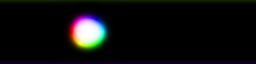

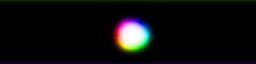

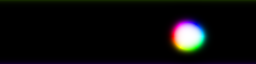

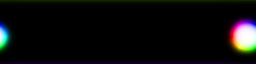

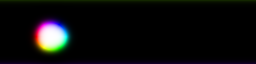

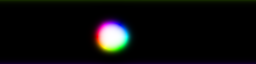

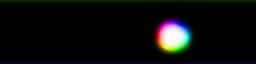

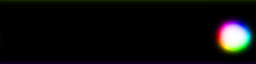

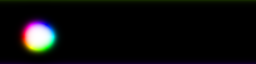

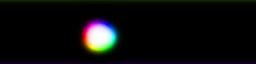

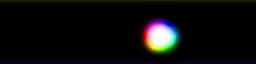

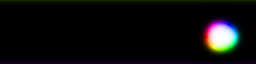

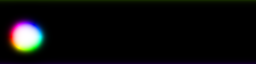

In [ ]:
from IPython.display import Image, display

for i in range(0, 26, 2):
    filename = f"example2_exercise21.out/m{i:06d}.png"
    display(Image(filename=filename))

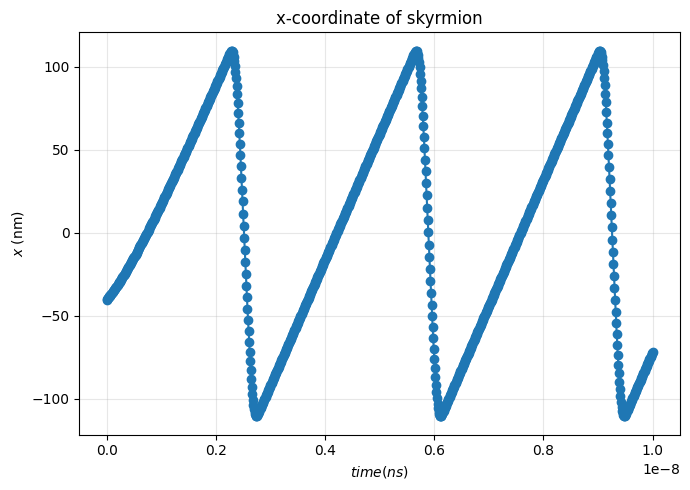

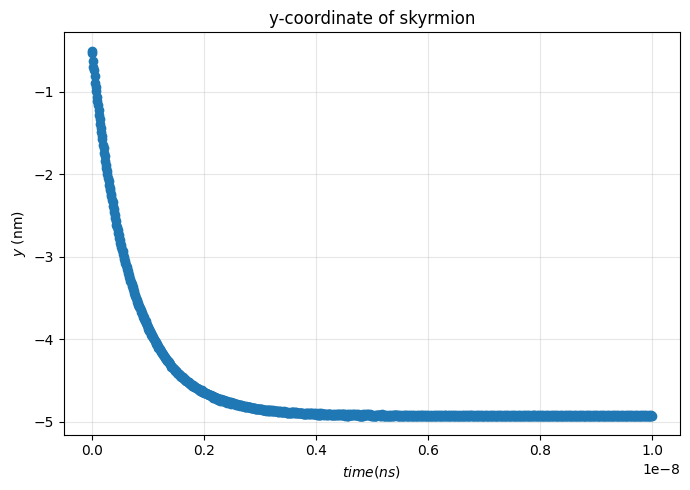

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the name of your data file
filename = "example2_exercise21.out/table.txt"

# Columns are counted from zero:
time, skyrm_x = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 4),
    unpack=True
)

plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_x*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$x$ (nm)")
plt.title(r"x-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()

filename = "example2_exercise21.out/table.txt"

# Columns are counted from zero:
time, skyrm_y = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 5),
    unpack=True
)
plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_y*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$y$ (nm)")
plt.title(r"y-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()


plt.savefig("skyrmion_pos.pdf")
plt.show()

**Observation**:
* Skyrmions get larger, since the smaller exchange coupling let DMI dominate the spiral like structure.
* in the limit $t\rightarrow \infty$, the Skyrmion gets faster. The entire skyrmion profile changes: Reducing the exchange stiffness also changes
  * the domain-wall width,
  * the helicity profile,
  * the dissipative tensor of the Thiele equation,
  * the pinning strength,
  * and sometimes even the effective value of $\beta$ in realistic materials.
  
  Suppose the skyrmion radius is $R$. The STT density scales like $\tau_{\rm STT}\sim\frac{u}{R}$. The area over which this torque acts scales as $A_{\rm sky}\sim R^2$. Therefore, the integrated driving force scales approximately as $F_{\rm drive}\sim \frac{u}{R}R^2\sim uR$.So a larger skyrmions experience a larger total driving force.
  
* the motion in y-direction and, thus, the SkyrHall effect get less dominant. This is because the effective value of $\beta$ in the Thiele equation gets changed.

## Solution Exercise 2.2

In [4]:
f = open('example2_exercise22.mx3', 'w')
a = """\
setgridsize(256,64,1)
setcellsize(1e-9,1e-9,1e-9)
setpbc(4,0,0)

Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0,0,1)
alpha = 0.1

m = neelskyrmion(-1, 1).transl(-40e-9,0,0)
minimize()

Pol = 0.4
xi = 0.2
j = vector(-2e12,0,0) // A/m2. //< made change here.

autosave(m,4e-10)
tableAutosave(1e-11)
tableAdd(ext_bubblepos)

run(10e-9)
"""
print(a,file=f)
f.close()

In [5]:
!mumax3 example2_exercise22.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.144
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: a919065e534b
//Timestamp: 2026-08-20 07:34:40
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example2_exercise22.out/
//starting GUI at http://127.0.0.1:35367
setgridsize(256, 64, 1)
setcellsize(1e-9, 1e-9, 1e-9)
setpbc(4, 0, 0)
//resizing...
Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0, 0, 1)
alpha = 0.1
m = neelskyrmion(-1,

In [6]:
!mumax3-convert -png example2_exercise22.out/*.ovf

example2_exercise22.out/m000000.ovf
example2_exercise22.out/m000001.ovf
example2_exercise22.out/m000002.ovf
example2_exercise22.out/m000003.ovf
example2_exercise22.out/m000004.ovf
example2_exercise22.out/m000005.ovf
example2_exercise22.out/m000006.ovf
example2_exercise22.out/m000007.ovf
example2_exercise22.out/m000008.ovf
example2_exercise22.out/m000009.ovf
example2_exercise22.out/m000010.ovf
example2_exercise22.out/m000011.ovf
example2_exercise22.out/m000012.ovf
example2_exercise22.out/m000013.ovf
example2_exercise22.out/m000014.ovf
example2_exercise22.out/m000015.ovf
example2_exercise22.out/m000016.ovf
example2_exercise22.out/m000017.ovf
example2_exercise22.out/m000018.ovf
example2_exercise22.out/m000019.ovf
example2_exercise22.out/m000020.ovf
example2_exercise22.out/m000021.ovf
example2_exercise22.out/m000022.ovf
example2_exercise22.out/m000023.ovf
example2_exercise22.out/m000024.ovf
example2_exercise22.out/m000025.ovf
[ ok ] example2_exercise22.out/m000000.ovf	-> example2_exercise2

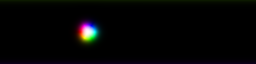

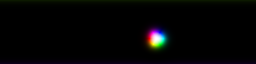

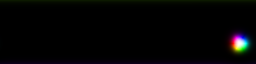

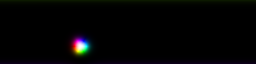

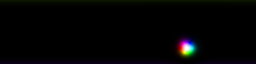

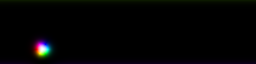

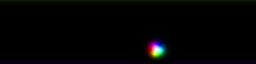

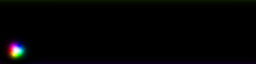

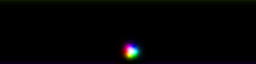

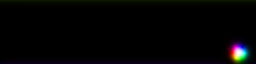

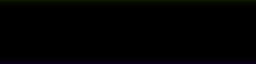

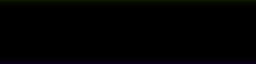

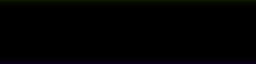

In [7]:
from IPython.display import Image, display

for i in range(0, 26, 2):
    filename = f"example2_exercise22.out/m{i:06d}.png"
    display(Image(filename=filename))

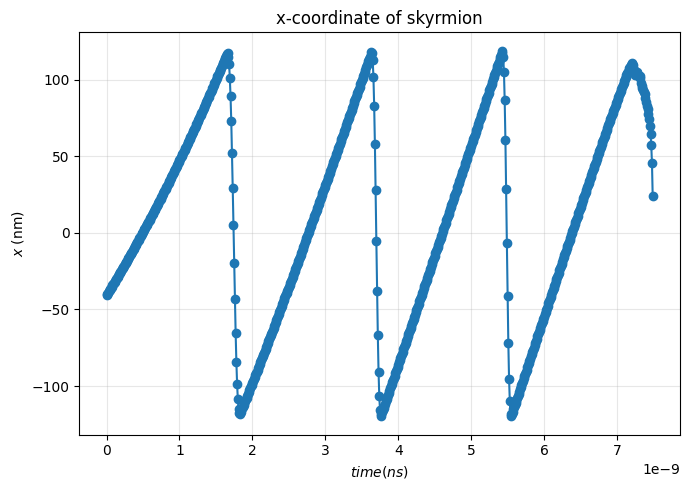

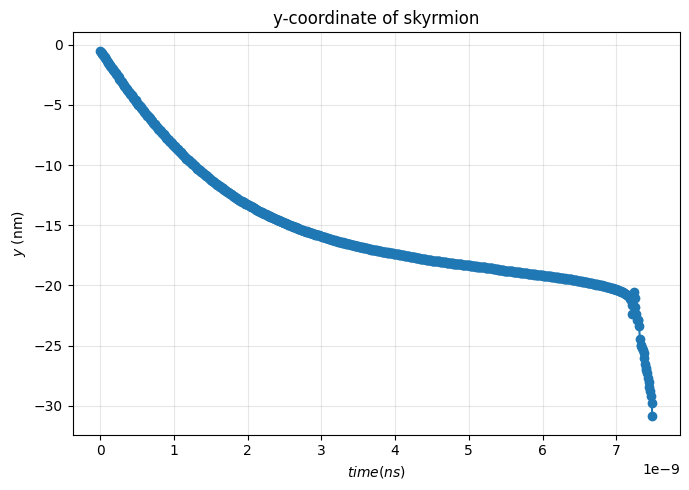

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the name of your data file
filename = "example2_exercise22.out/table.txt"

# Columns are counted from zero:
time, skyrm_x = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 4),
    unpack=True
)

plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_x*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$x$ (nm)")
plt.title(r"x-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()

filename = "example2_exercise22.out/table.txt"

# Columns are counted from zero:
time, skyrm_y = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 5),
    unpack=True
)
plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_y*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$y$ (nm)")
plt.title(r"y-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()


plt.savefig("example2_exercise22.out/skyrmion_pos.pdf")
plt.show()

**Observation**
* Larger currents speed up the skyrmion, since for an ideal infinite film, $v_x=\frac{\beta}{\alpha}u$.
* The Skyrmion reaches the boundary and disappears.


## Solution Exercise 2.3

In [ ]:
f = open('example2_exercise23_1.mx3', 'w')
a = """\
setgridsize(256,64,1)
setcellsize(1e-9,1e-9,1e-9)
setpbc(4,0,0)

Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0,0,1)
alpha = 0.1

m = neelskyrmion(-1, 1).transl(-40e-9,0,0)
minimize()

Pol = 0.4
xi = 0.1
j = vector(-1e12,0,0) // A/m2

autosave(m,4e-10)
tableAutosave(1e-11)
tableAdd(ext_bubblepos)

run(10e-9)
"""
print(a,file=f)
f.close()

In [ ]:
!mumax3 example2_exercise23_1.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 12:16:46
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example2_exercise22.out/
//starting GUI at http://127.0.0.1:35367
setgridsize(256, 64, 1)
setcellsize(1e-9, 1e-9, 1e-9)
setpbc(4, 0, 0)
//resizing...
Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0, 0, 1)
alpha = 0.1
m = neelskyrmion(-1,

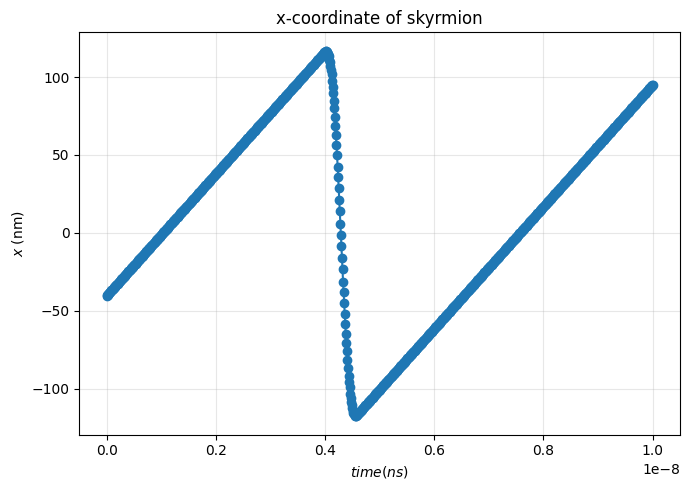

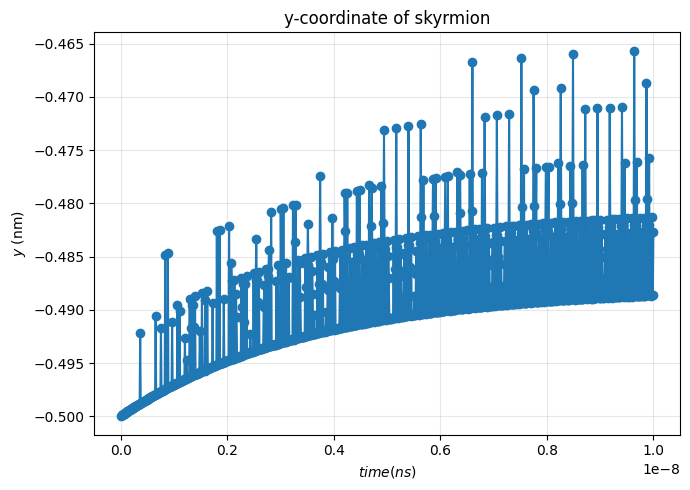

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the name of your data file
filename = "example2_exercise23_1.out/table.txt"

# Columns are counted from zero:
time, skyrm_x = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 4),
    unpack=True
)

plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_x*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$x$ (nm)")
plt.title(r"x-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()

filename = "example2_exercise23_1.out/table.txt"

# Columns are counted from zero:
time, skyrm_y = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 5),
    unpack=True
)
plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_y*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$y$ (nm)")
plt.title(r"y-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()


plt.savefig("skyrmion_pos.pdf")
plt.show()

# Position in nm:
x_nm = skyrm_x * 1e9
y_nm = skyrm_y * 1e9
#vx_fit, x0 = np.polyfit(time, x_nm, 1)
#vy_fit, y0 = np.polyfit(time, y_nm, 1)
#print(f"vx from linear fit = {vx_fit:.6e} m/s")
#print(f"vy from linear fit = {vy_fit:.6e} m/s")
#print(f"vx/vy from linear fit = {vx_fit / vy_fit:.6e}")
# Since nm/ns is numerically equal to m/s:

# vx = np.gradient(x_nm, time)   # nm/ns = m/s
# vy = np.gradient(y_nm, time)   # nm/ns = m/s
# print(vx[0])
# plt.plot(time, vx, marker="o", linestyle="-")
# plt.xlim(0,0.3e-8)

**Observation**


$\xi=\alpha$: The Skyrmion is moving strait without a Hall effect. For a rigid skyrmion driven by spin-transfer torque (STT), the Thiele equation is

$\mathbf{G}\times(\mathbf{v}-\mathbf{u})
+\mathbf{D}(\alpha\mathbf{v}-\xi\mathbf{u})=0$,

where
* $\mathbf{v}$ is the skyrmion velocity,
* $\mathbf{u}$ is the electron spin drift velocity,
* $\mathbf{G}$ is the gyrovector,
* $\mathbf{D}$ is the dissipative tensor.

The first term,

$\mathbf{G}\times(\mathbf{v}-\mathbf{u})$,

is the gyroscopic (Magnus) force. Because it is a cross product, it always acts perpendicular to the relative velocity $(\mathbf{v}-\mathbf{u})$. This is the term responsible for the skyrmion Hall effect.

The second term,

$\mathbf{D}(\alpha\mathbf{v}-\xi\mathbf{u})$,

is dissipative and acts parallel to the motion. Suppose $\alpha=\xi$. Then

$\alpha\mathbf{v}-\xi\mathbf{u}
=
\alpha(\mathbf{v}-\mathbf{u})$,

and the Thiele equation becomes

$\mathbf{G}\times(\mathbf{v}-\mathbf{u})
+\alpha\mathbf{D}(\mathbf{v}-\mathbf{u})=0$.

Notice that both terms depend only on

$\mathbf{v}-\mathbf{u}$ and $\mathbf{v}=\mathbf{u}$ is a solution. The skyrmion is simply carried along with the spin current. Since its velocity is exactly parallel to the current, $v_y=0$, and therefore $\theta_{\rm Hall}=0$.

In [9]:
f = open('example2_exercise23_2.mx3', 'w')
a = """\
setgridsize(256,64,1)
setcellsize(1e-9,1e-9,1e-9)
setpbc(4,0,0)

Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0,0,1)
alpha = 0.1

m = neelskyrmion(-1, 1).transl(-40e-9,0,0)
minimize()

Pol = 0.4
xi = 0.3
j = vector(-1e12,0,0) // A/m2

autosave(m,4e-10)
tableAutosave(1e-11)
tableAdd(ext_bubblepos)

run(10e-9)
"""
print(a,file=f)
f.close()

In [ ]:
!mumax3 example2_exercise23_2.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 12:44:32
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example2_exercise22_2.out/
//starting GUI at http://127.0.0.1:35367
setgridsize(256, 64, 1)
setcellsize(1e-9, 1e-9, 1e-9)
setpbc(4, 0, 0)
//resizing...
Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0, 0, 1)
alpha = 0.1
m = neelskyrmion(-

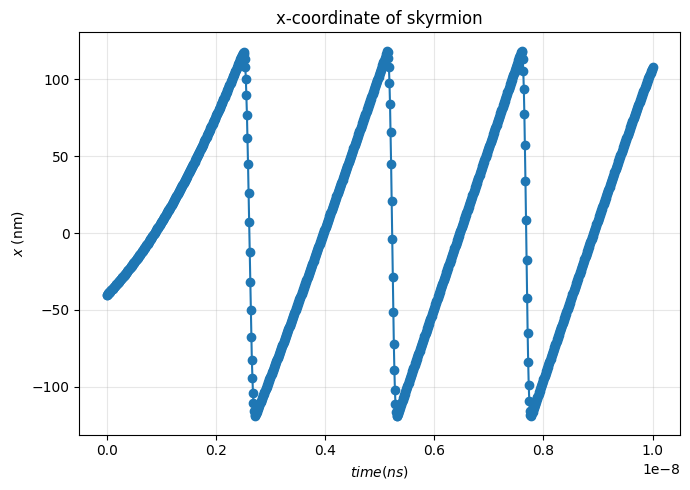

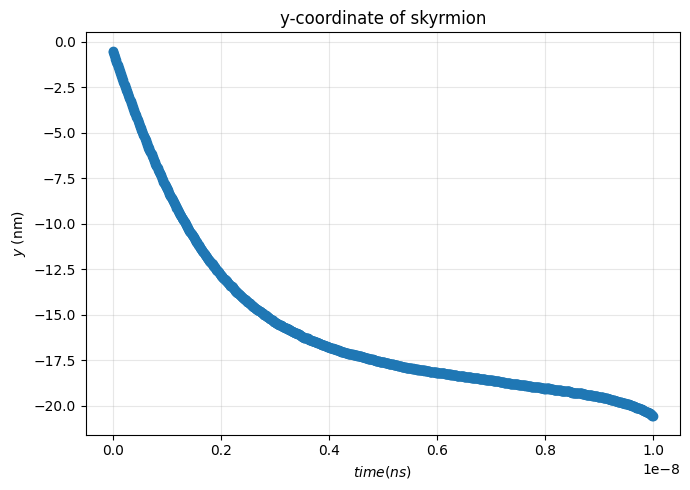

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the name of your data file
filename = "example2_exercise23_2.out/table.txt"

# Columns are counted from zero:
time, skyrm_x = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 4),
    unpack=True
)

plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_x*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$x$ (nm)")
plt.title(r"x-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()

filename = "example2_exercise23_2.out/table.txt"

# Columns are counted from zero:
time, skyrm_y = np.loadtxt(
    filename,
    skiprows=1,
    usecols=(0, 5),
    unpack=True
)
plt.figure(figsize=(7, 5))
plt.plot(time, skyrm_y*1E9, marker="o", linestyle="-")
plt.xlabel(r"$time (ns)$")
plt.ylabel(r"$y$ (nm)")
plt.title(r"y-coordinate of skyrmion")
plt.grid(True, alpha=0.3)
plt.tight_layout()


plt.savefig("skyrmion_pos.pdf")
plt.show()

# Position in nm:
x_nm = skyrm_x * 1e9
y_nm = skyrm_y * 1e9
#vx_fit, x0 = np.polyfit(time, x_nm, 1)
#vy_fit, y0 = np.polyfit(time, y_nm, 1)
#print(f"vx from linear fit = {vx_fit:.6e} m/s")
#print(f"vy from linear fit = {vy_fit:.6e} m/s")
#print(f"vx/vy from linear fit = {vx_fit / vy_fit:.6e}")
# Since nm/ns is numerically equal to m/s:

# vx = np.gradient(x_nm, time)   # nm/ns = m/s
# vy = np.gradient(y_nm, time)   # nm/ns = m/s
# print(vx[0])
# plt.plot(time, vx, marker="o", linestyle="-")
# plt.xlim(0,0.3e-8)

**Observation**
Following all previous explanations, a larger $\xi$ is accelerating the Skyrmion, similar to increased current. The Skyrmion moves closer to the boundary due to larger Hall angle.

## Solution Exercise 2.4

In [ ]:
f = open('example2_exercise24.mx3', 'w')
a = """\
setgridsize(256,64,1)
setcellsize(1e-9,1e-9,1e-9)
setpbc(4,0,0)

Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0,0,1)
alpha = 0.1

m = neelskyrmion(1, -1).transl(-40e-9,0,0)
minimize()

Pol = 0.4
xi = 0.2
j = vector(-1e12,0,0) // A/m2

autosave(m,4e-10)
tableAutosave(1e-11)
tableAdd(ext_bubblepos)

run(10e-9)
"""
print(a,file=f)
f.close()

In [ ]:
!mumax3 example2_exercise24.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.150
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: 14fb70a6932a
//Timestamp: 2026-08-04 13:06:30
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example2_exercise24.out/
//starting GUI at http://127.0.0.1:35367
setgridsize(256, 64, 1)
setcellsize(1e-9, 1e-9, 1e-9)
setpbc(4, 0, 0)
//resizing...
Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0, 0, 1)
alpha = 0.1
m = neelskyrmion(1, 

In [ ]:
!mumax3-convert -png example2_exercise24.out/*.ovf

example2_exercise24.out/m000000.ovf
example2_exercise24.out/m000001.ovf
example2_exercise24.out/m000002.ovf
example2_exercise24.out/m000003.ovf
example2_exercise24.out/m000004.ovf
example2_exercise24.out/m000005.ovf
example2_exercise24.out/m000006.ovf
example2_exercise24.out/m000007.ovf
example2_exercise24.out/m000008.ovf
example2_exercise24.out/m000009.ovf
example2_exercise24.out/m000010.ovf
example2_exercise24.out/m000011.ovf
example2_exercise24.out/m000012.ovf
example2_exercise24.out/m000013.ovf
example2_exercise24.out/m000014.ovf
example2_exercise24.out/m000015.ovf
example2_exercise24.out/m000016.ovf
example2_exercise24.out/m000017.ovf
example2_exercise24.out/m000018.ovf
example2_exercise24.out/m000019.ovf
example2_exercise24.out/m000020.ovf
example2_exercise24.out/m000021.ovf
example2_exercise24.out/m000022.ovf
example2_exercise24.out/m000023.ovf
example2_exercise24.out/m000024.ovf
example2_exercise24.out/m000025.ovf
[ ok ] example2_exercise24.out/m000001.ovf	-> example2_exercise2

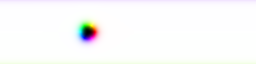

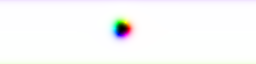

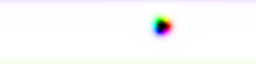

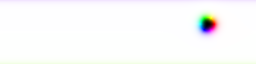

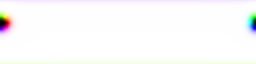

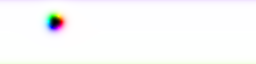

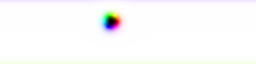

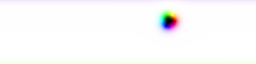

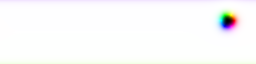

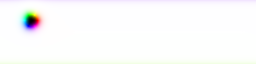

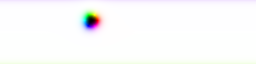

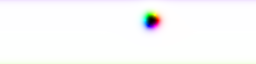

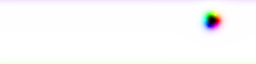

In [ ]:
from IPython.display import Image, display

for i in range(0, 26, 2):
    filename = f"example2_exercise24.out/m{i:06d}.png"
    display(Image(filename=filename))

**Observation**

Here, we use the two examples:
* Neel Skyrmion, winding 1 and polarisation 1
* Neel Skyrmion, winding 1 and polarisation -1

From the output, we observe that the first Skyrmion is not stable and fast disappears. The seconde is also stable and dynamics is similar to the original case.

Other combinations are:
* Neel Skyrmion, winding -1 and polarisation -1
* Bloch Skyrmion, winding -1 and polarisation 1
* Bloch Skyrmion, winding 1 and polarisation 1
* Bloch Skyrmion, winding 1 and polarisation -1
* Bloch Skyrmion, winding -1 and polarisation -1

## Solution Exercise 2.5
(might take a long time; approx 32min)

In [17]:
f = open('example2_exercise25.mx3', 'w')
a = """\
setgridsize(256,64,1)
setcellsize(1e-9,1e-9,1e-9)
setpbc(4,0,0)

Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0,0,1)
alpha = 0.1
Temp = 100

m = neelskyrmion(-1, 1).transl(-40e-9,0,0)
minimize()

Pol = 0.4
xi = 0.2
j = vector(-1e12,0,0) // A/m2

autosave(m,4e-10)
tableAutosave(1e-11)
tableAdd(ext_bubblepos)

run(10e-9)
"""
print(a,file=f)
f.close()

In [18]:
!mumax3 example2_exercise25.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.144
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: a919065e534b
//Timestamp: 2026-08-20 09:11:01
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example2_exercise25.out/
//starting GUI at http://127.0.0.1:35367
setgridsize(256, 64, 1)
setcellsize(1e-9, 1e-9, 1e-9)
setpbc(4, 0, 0)
//resizing...
Msat = 580e3
Aex = 15e-12
Dind = 3.0e-3
Ku1 = 0.8e6
AnisU = vector(0, 0, 1)
alpha = 0.1
Temp = 100
m = neels

In [19]:
!mumax3-convert -png example2_exercise25.out/*.ovf

example2_exercise25.out/m000000.ovf
example2_exercise25.out/m000001.ovf
example2_exercise25.out/m000002.ovf
example2_exercise25.out/m000003.ovf
example2_exercise25.out/m000004.ovf
example2_exercise25.out/m000005.ovf
example2_exercise25.out/m000006.ovf
example2_exercise25.out/m000007.ovf
example2_exercise25.out/m000008.ovf
example2_exercise25.out/m000009.ovf
example2_exercise25.out/m000010.ovf
example2_exercise25.out/m000011.ovf
example2_exercise25.out/m000012.ovf
example2_exercise25.out/m000013.ovf
example2_exercise25.out/m000014.ovf
example2_exercise25.out/m000015.ovf
example2_exercise25.out/m000016.ovf
example2_exercise25.out/m000017.ovf
example2_exercise25.out/m000018.ovf
example2_exercise25.out/m000019.ovf
example2_exercise25.out/m000020.ovf
example2_exercise25.out/m000021.ovf
example2_exercise25.out/m000022.ovf
example2_exercise25.out/m000023.ovf
example2_exercise25.out/m000024.ovf
example2_exercise25.out/m000025.ovf
[ ok ] example2_exercise25.out/m000002.ovf	-> example2_exercise2

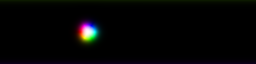

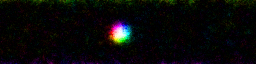

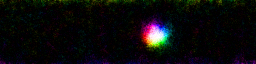

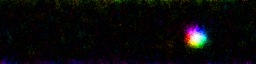

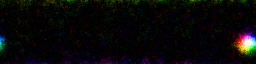

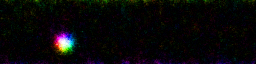

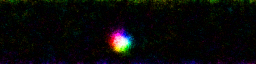

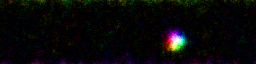

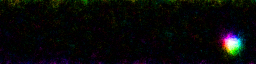

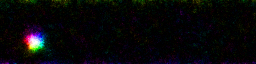

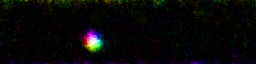

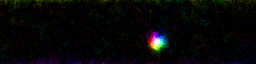

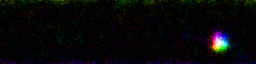

In [20]:
from IPython.display import Image, display

for i in range(0, 26, 2):
    filename = f"example2_exercise25.out/m{i:06d}.png"
    display(Image(filename=filename))

**Observation**
* Randomness added to the Skyrmion.
* Skyrmion seem to have some breathing: it increases and decreases again.

# Example 3 of Mumax Tutorial - Hysteresis

## Exercise 3
1. (Optional) Repeat the simulation with a smaller B_step, for example 0.001. What features in the hystereses can you observe?
2. (Optional) Change the angle $\alpha$ to 90 degree. What do you observe?
3. (Optional) Increase drastically the magnetocrystalline anisotropy Ku1 to 10e3. What do you observe?

## Solution Exercise 3.1
(this maybe take some time, approx. 12min )

In [25]:
f = open('example3_exercise31.mx3', 'w')
a = """\
SetGridsize(192,384, 1)
SetCellsize(1000e-9/192,2000e-9/384,20e-9)

Msat  = 800e3
Aex   = 13e-12
alpha = 0.02
Ku1   = 5e2
anisu = vector(0,1,0)

m = uniform(-0.1,-1,0)

angle  := pi/180  //1 degree
B_ext   = vector( -0.05*sin(angle) , -0.05*cos(angle) , 0)
tableadd(B_ext)
relax()

B_min  := -0.05
B_max  :=  0.05
B_step :=  0.001

//ramp the field up
for B:=B_min; B<=B_max; B+=B_step {
    B_ext = vector(B*sin(angle), B*cos(angle), 0)
    minimize()
    tablesave()
    snapshot(m)
}

//ramp the field down
for B:=B_max; B>=B_min; B-=B_step {
    B_ext = vector(B*sin(angle), B*cos(angle), 0)
    minimize()
    tablesave()
    snapshot(m)
}
"""
print(a,file=f)
f.close()

In [26]:
!mumax3 example3_exercise31.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.232
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: e9d4b4145031
//Timestamp: 2026-08-20 11:44:05
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example3_exercise31.out/
//starting GUI at http://127.0.0.1:35367
SetGridsize(192, 384, 1)
SetCellsize(1000e-9/192, 2000e-9/384, 20e-9)
Msat = 800e3
Aex = 13e-12
alpha = 0.02
Ku1 = 5e2
anisu = vector(0, 1, 0)
m = uniform(-0.1, -1, 0)
angle := pi / 180
B_ext 

Lets plot the hysteresis curve along the axis determined by $\alpha$.

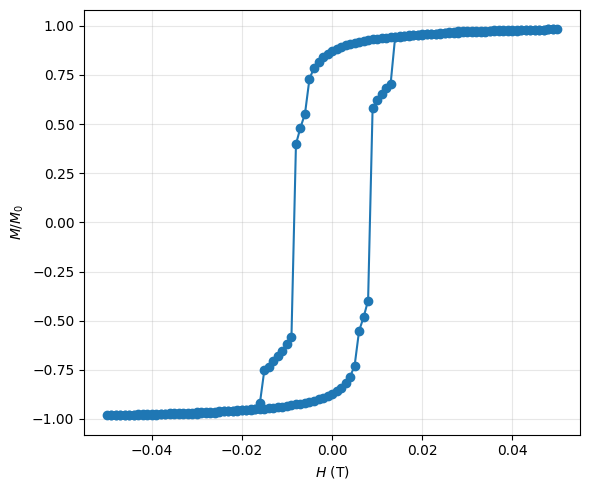

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = np.loadtxt("example3_exercise31.out/table.txt", skiprows=1)

# Magnetization
mx, my, mz = data[:,1], data[:,2], data[:,3]

# External field
Bx, By, Bz = data[:,4], data[:,5], data[:,6]

# Projection M and B
angle = np.pi/180
projm = mx*np.sin(angle) + my*np.cos(angle)

projB = Bx*np.sin(angle)+ By*np.cos(angle)

# Plot
plt.figure(figsize=(6,5))
plt.plot(projB, projm, 'o-', markersize=6)
plt.ylabel(r'$M/M_0$')
plt.xlabel(r'$H$ (T)')

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("example3_exercise31.out/M_vs_B.pdf")

plt.show()

**Observation**

The magnetization reversal is not occurring uniformly, but through a sequence of discrete changes in the magnetic state. This comes from nucleation and propagation of domains. The system can sit in a metastable state over a finite field interval, then suddenly cross an instability and reorganize into a new configuration. That produces a jump in the spatially averaged magnetization.

## Solution Exercise 3.2

In [9]:
f = open('example3_exercise32.mx3', 'w')
a = """\
SetGridsize(192,384, 1)
SetCellsize(1000e-9/192,2000e-9/384,20e-9)

Msat  = 800e3
Aex   = 13e-12
alpha = 0.02
Ku1   = 5e2
anisu = vector(0,1,0)

m = uniform(-0.1,-1,0)

angle  := 90*pi/180  //15 degree
B_ext   = vector( -0.05*sin(angle) , -0.05*cos(angle) , 0)
tableadd(B_ext)
relax()

B_min  := -0.05
B_max  :=  0.05
B_step :=  0.01

//ramp the field up
for B:=B_min; B<=B_max; B+=B_step {
    B_ext = vector(B*sin(angle), B*cos(angle), 0)
    minimize()
    tablesave()
    snapshot(m)
}

//ramp the field down
for B:=B_max; B>=B_min; B-=B_step {
    B_ext = vector(B*sin(angle), B*cos(angle), 0)
    minimize()
    tablesave()
    snapshot(m)
}
"""
print(a,file=f)
f.close()

In [10]:
!mumax3 example3_exercise32.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.232
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: e9d4b4145031
//Timestamp: 2026-08-20 11:18:58
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example3_exercise32.out/
//starting GUI at http://127.0.0.1:35367
SetGridsize(192, 384, 1)
SetCellsize(1000e-9/192, 2000e-9/384, 20e-9)
Msat = 800e3
Aex = 13e-12
alpha = 0.02
Ku1 = 5e2
anisu = vector(0, 1, 0)
m = uniform(-0.1, -1, 0)
angle := 90 * pi / 180
B

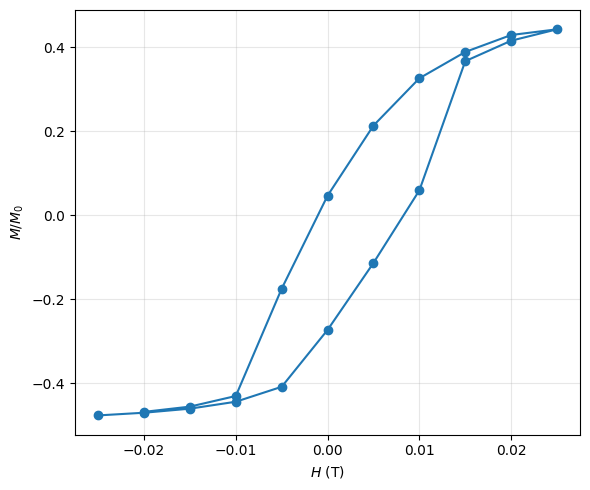

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = np.loadtxt("example3_exercise32.out/table.txt", skiprows=1)

# Magnetization
mx, my, mz = data[:,1], data[:,2], data[:,3]

# External field
Bx, By, Bz = data[:,4], data[:,5], data[:,6]

# Projection M and B
angle = 30*np.pi/180
projm = mx*np.sin(angle) + my*np.cos(angle)

projB = Bx*np.sin(angle)+ By*np.cos(angle)

# Plot
plt.figure(figsize=(6,5))
plt.plot(projB, projm, 'o-', markersize=6)
plt.ylabel(r'$M/M_0$')
plt.xlabel(r'$H$ (T)')

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("example3_exercise32.out/M_vs_B.pdf")

plt.show()

**Observation**

We are probing the "soft" axis perpendicular to the anisotropy direction. Hysteresis is expected to vanish.

## Solution Exercise 3.3

In [22]:
f = open('example3_exercise33.mx3', 'w')
a = """\
SetGridsize(192,384, 1)
SetCellsize(1000e-9/192,2000e-9/384,20e-9)

Msat  = 800e3
Aex   = 13e-12
alpha = 0.02
Ku1   = 10e3
anisu = vector(0,1,0)

m = uniform(-0.1,-1,0)

angle  := pi/180  //1 degree
B_ext   = vector( -0.05*sin(angle) , -0.05*cos(angle) , 0)
tableadd(B_ext)
relax()

B_min  := -0.05
B_max  :=  0.05
B_step :=  0.01

//ramp the field up
for B:=B_min; B<=B_max; B+=B_step {
    B_ext = vector(B*sin(angle), B*cos(angle), 0)
    minimize()
    tablesave()
    snapshot(m)
}

//ramp the field down
for B:=B_max; B>=B_min; B-=B_step {
    B_ext = vector(B*sin(angle), B*cos(angle), 0)
    minimize()
    tablesave()
    snapshot(m)
}
"""
print(a,file=f)
f.close()

In [23]:
!mumax3 example3_exercise33.mx3

//mumax 3.12 [linux_amd64 go1.22.4(gc) CUDA-12.9]
//commit hash: 6e5c98bb
//CPU info: Intel(R) Xeon(R) CPU @ 2.00GHz, Cores: 1, MHz: 2000.232
//GPU info: Tesla T4(14912MB), CUDA Driver 13.0, cc=7.5, using cc=75 PTX
//OS  info: Ubuntu 22.04.5 LTS, Hostname: e9d4b4145031
//Timestamp: 2026-08-20 11:35:43
//(c) Arne Vansteenkiste, Dynamat LAB, Ghent University, Belgium
//This is free software without any warranty. See license.txt
//********************************************************************//
//  If you use mumax in any work or publication,                      //
//  we kindly ask you to cite the references in references.bib        //
//********************************************************************//
//output directory: example3_exercise33.out/
//starting GUI at http://127.0.0.1:35367
SetGridsize(192, 384, 1)
SetCellsize(1000e-9/192, 2000e-9/384, 20e-9)
Msat = 800e3
Aex = 13e-12
alpha = 0.02
Ku1 = 10e3
anisu = vector(0, 1, 0)
m = uniform(-0.1, -1, 0)
angle := pi / 180
B_ext

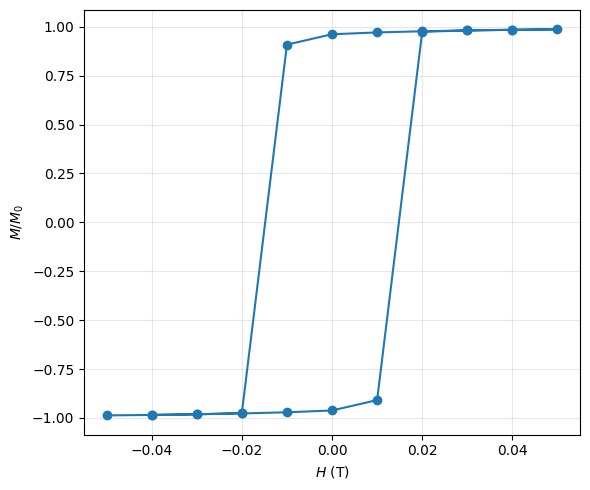

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = np.loadtxt("example3_exercise33.out/table.txt", skiprows=1)

# Magnetization
mx, my, mz = data[:,1], data[:,2], data[:,3]

# External field
Bx, By, Bz = data[:,4], data[:,5], data[:,6]

# Projection M and B
angle = np.pi/180
projm = mx*np.sin(angle) + my*np.cos(angle)

projB = Bx*np.sin(angle)+ By*np.cos(angle)

# Plot
plt.figure(figsize=(6,5))
plt.plot(projB, projm, 'o-', markersize=6)
plt.ylabel(r'$M/M_0$')
plt.xlabel(r'$H$ (T)')

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("example3_exercise33.out/M_vs_B.pdf")

plt.show()

**Observation**

According to Stoner-Wohlfarth law for a single domain, the coercive field is proportional to the magnetocrystalline anisotropy.  

$H_c \propto \frac{2K}{\mu_0 M_s}$,

As expected, increasing the anisotropy leads to a significant increase in the coercive field. At the same time, the number of intermediate metastable states is reduced, resulting in a more abrupt magnetization reversal.